# Results

Loads saved metrics/history from `results/` and produces the figures used in
the top-level README. Run this after `scripts/run_all_experiments.sh` finishes.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path('../results')

def load_history(kind, run_name):
    with open(RESULTS / kind / run_name / 'history.json') as f:
        return json.load(f)

def load_eval(run_name, split):
    tag = f"{run_name}__{split.replace('/', '_')}"
    with open(RESULTS / 'tables' / f'{tag}.json') as f:
        return json.load(f)

## 1-1: Architecture comparison (baseline / wide / deep)

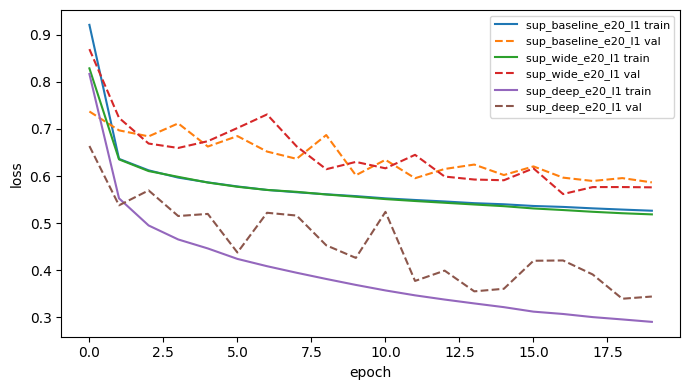

In [2]:
arch_runs = ['sup_baseline_e20_l1', 'sup_wide_e20_l1', 'sup_deep_e20_l1']

fig, ax = plt.subplots(figsize=(7, 4))
for run in arch_runs:
    h = load_history('supervised', run)
    ax.plot(h['train_loss'], label=f'{run} train')
    ax.plot(h['val_loss'], '--', label=f'{run} val')
ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig('../results/figures/arch_loss_curves.png', dpi=150)

In [3]:
rows = []
for run in arch_runs:
    e = load_eval(run, 'test/Distance10mm')
    rows.append({'model': run, 'psnr': e['psnr']['mean'], 'ssim': e['ssim']['mean']})
pd.DataFrame(rows)

,model,psnr,ssim
0,sup_baseline_e20_l1,20.616350,0.391053
1,sup_wide_e20_l1,20.790450,0.409112
2,sup_deep_e20_l1,21.428709,0.517330


## 1-2: Epoch comparison (deep, 10 / 20 / 50 epochs)

In [4]:
epoch_runs = {10: 'sup_deep_e10_l1', 20: 'sup_deep_e20_l1', 50: 'sup_deep_e50_l1'}
rows = []
for n_epochs, run in epoch_runs.items():
    e = load_eval(run, 'test/Distance10mm')
    rows.append({'epochs': n_epochs, 'psnr': e['psnr']['mean'], 'ssim': e['ssim']['mean']})
pd.DataFrame(rows)

,epochs,psnr,ssim
0,10,20.902909,0.471760
1,20,21.428709,0.517330
2,50,21.796065,0.560933


## 1-3: Loss function comparison (L1 / L2 / L1+SSIM)

In [5]:
loss_runs = {'L1': 'sup_deep_e20_l1', 'L2': 'sup_deep_e20_l2', 'L1+SSIM': 'sup_deep_e20_l1ssim'}
rows = []
for name, run in loss_runs.items():
    e = load_eval(run, 'test/Distance10mm')
    rows.append({'loss': name, 'psnr': e['psnr']['mean'], 'ssim': e['ssim']['mean']})
pd.DataFrame(rows)

,loss,psnr,ssim
0,L1,21.428709,0.517330
1,L2,20.846918,0.468343
2,L1+SSIM,22.518676,0.695748


## 1-4: Generalization across distances (5 / 10 / 15 / 20mm)

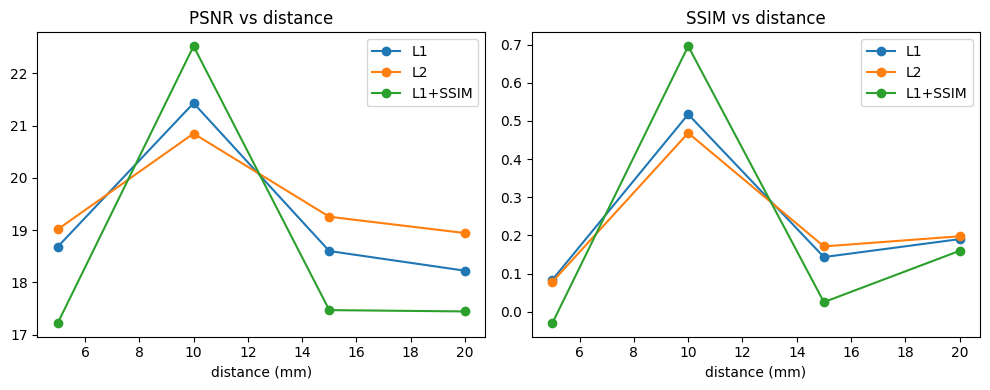

In [6]:
distances = [5, 10, 15, 20]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for name, run in loss_runs.items():
    psnrs, ssims = [], []
    for d in distances:
        e = load_eval(run, f'test/Distance{d}mm')
        psnrs.append(e['psnr']['mean']); ssims.append(e['ssim']['mean'])
    axes[0].plot(distances, psnrs, marker='o', label=name)
    axes[1].plot(distances, ssims, marker='o', label=name)
axes[0].set_title('PSNR vs distance'); axes[1].set_title('SSIM vs distance')
for ax in axes: ax.set_xlabel('distance (mm)'); ax.legend()
fig.tight_layout()
fig.savefig('../results/figures/generalization.png', dpi=150)

## 2-1: Self-supervised, cross-distance evaluation

In [7]:
ss_runs = ['ss_5_5', 'ss_10_10', 'ss_15_15', 'ss_20_20', 'ss_5_20']
table = {}
for run in ss_runs:
    row = {}
    for d in distances:
        e = load_eval(run, f'test/Distance{d}mm')
        row[f'{d}mm PSNR'] = e['psnr']['mean']
        row[f'{d}mm SSIM'] = e['ssim']['mean']
    table[run] = row
pd.DataFrame(table).T

,5mm PSNR,5mm SSIM,10mm PSNR,10mm SSIM,15mm PSNR,15mm SSIM,20mm PSNR,20mm SSIM
ss_5_5,21.237324,0.604569,17.543573,0.093864,17.859571,0.195326,17.613611,0.216547
ss_10_10,19.352228,0.102774,20.646134,0.385220,19.485893,0.225426,18.987272,0.208816
ss_15_15,19.868083,0.255775,20.201504,0.276076,20.290275,0.283546,19.959663,0.265066
ss_20_20,20.279612,0.319590,19.874477,0.234138,20.069848,0.266416,19.950186,0.272785
ss_5_20,20.145992,0.284827,20.388434,0.306018,20.176392,0.271783,19.904410,0.258834


## 2-2: Distance estimation (auto-focus)

In [8]:
with open(RESULTS / 'depth_regressor' / 'depth_5_20' / 'history.json') as f:
    depth_hist = json.load(f)
pd.DataFrame(depth_hist['eval']).T

,mae,mse,mean_predicted
5,6.857501,47.140236,11.857501
10,4.864187,25.780346,14.864187
15,1.001588,1.336294,14.525914
20,4.967677,27.283665,15.032323


## Extra credit: OOD comparison (2mm / 25mm)

In [9]:
with open(RESULTS / 'tables' / 'ood_comparison.json') as f:
    ood = json.load(f)
pd.DataFrame({k: {'psnr': v['psnr']['mean'], 'ssim': v['ssim']['mean']} for k, v in ood.items()}).T

,psnr,ssim
supervised_2.0mm,17.469623,0.204860
selfsupervised_2.0mm,18.707739,0.211427
supervised_25.0mm,17.376692,0.156888
selfsupervised_25.0mm,19.832043,0.259901
